In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/Cleaned_Dataset_IntermodalRail.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 257
Columns: 19


In [3]:
df["remaining_shelf_life_days"].describe()

count    257.000000
mean       8.997276
std        7.318205
min        1.500000
25%        4.700000
50%        6.000000
75%       10.200000
max       29.100000
Name: remaining_shelf_life_days, dtype: float64

In [4]:
low_shelf = df[
    df["remaining_shelf_life_days"] <= 2
]

print("Shipments with 2 days or less shelf life:")
print(low_shelf)

Shipments with 2 days or less shelf life:
   shipment_id   transport_mode recorded_date recorded_time  \
70    RAIL0899  Intermodal Rail    2024-07-01         13:40   

      recorded_datetime origin_location destination_location cargo_type  \
70  2024-07-01 13:40:00       Ahmedabad                Jammu    Seafood   

    temperature_celsius  humidity_percentage  vibration_level  pressure_kpa  \
70                  7.9                 67.4              1.4           0.0   

    exposure_duration_hours  door_open_count  salinity_ppt  \
70                    138.5                0           0.0   

    thermal_leakage_score  spoilage_risk_percent  remaining_shelf_life_days  \
70                    9.5                   89.9                        1.5   

   spoilage_status  
70         Spoiled  


In [5]:
print(
    "Number of low shelf-life shipments:",
    len(low_shelf)
)

Number of low shelf-life shipments: 1


In [6]:
low_shelf_risk = low_shelf[
    [
        "shipment_id",
        "remaining_shelf_life_days",
        "spoilage_risk_percent"
    ]
]

print(low_shelf_risk)

   shipment_id  remaining_shelf_life_days  spoilage_risk_percent
70    RAIL0899                        1.5                   89.9


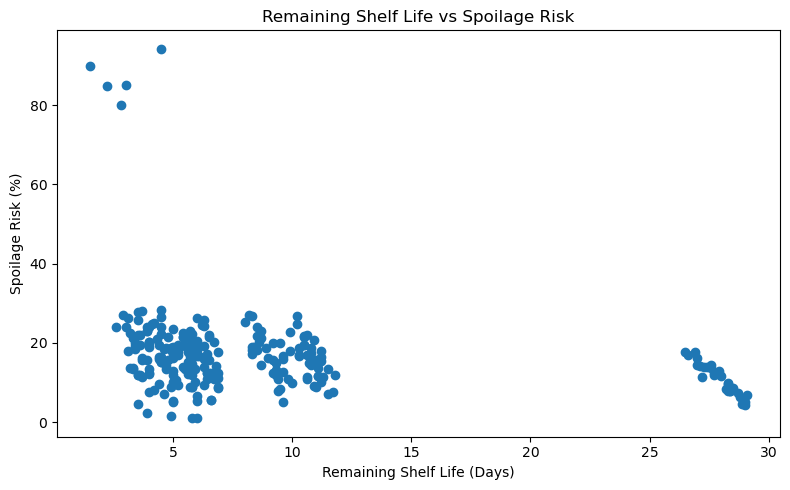

In [7]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["remaining_shelf_life_days"],
    df["spoilage_risk_percent"]
)

plt.title("Remaining Shelf Life vs Spoilage Risk")
plt.xlabel("Remaining Shelf Life (Days)")
plt.ylabel("Spoilage Risk (%)")

plt.tight_layout()
plt.show()

In [8]:
shelf_risk_correlation = df[
    "remaining_shelf_life_days"
].corr(
    df["spoilage_risk_percent"]
)

print(
    "Shelf Life vs Spoilage Risk Correlation:",
    shelf_risk_correlation
)

Shelf Life vs Spoilage Risk Correlation: -0.26879624076654224
